In [1]:
 # ============================================================
# NB2 · Cell 1 — Setup, GPU check, dataset path discovery
# ============================================================
import os, sys, json, random, time
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print()

# Dataset path auto-discovery
candidates = [
    "/kaggle/input/plantvillage-dataset/color",
    "/kaggle/input/plantvillage-dataset/plantvillage dataset/color",
    "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color",
]
COLOR_DIR = None
for c in candidates:
    if os.path.isdir(c) and any("Corn" in d for d in os.listdir(c)):
        COLOR_DIR = c
        break
if COLOR_DIR is None:
    print("⚠️  Couldn't find dataset at expected paths. Listing /kaggle/input:")
    for d in sorted(os.listdir("/kaggle/input")):
        print(f"  {d}")
    raise FileNotFoundError("Inspect structure above and set COLOR_DIR manually.")

maize_dirs = sorted([d for d in os.listdir(COLOR_DIR) if "Corn" in d])
assert len(maize_dirs) == 4, f"Expected 4 maize folders, got {len(maize_dirs)}"

print(f"Dataset path : {COLOR_DIR}")
print(f"Maize classes: {len(maize_dirs)}")
for d in maize_dirs:
    n = sum(1 for f in os.listdir(os.path.join(COLOR_DIR, d))
            if f.lower().endswith((".jpg", ".jpeg", ".png")))
    print(f"  {n:>5} images  {d}")

print("\nCell 1 complete ✅")

Device : cuda
GPU    : Tesla T4

Dataset path : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Maize classes: 4
    513 images  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   1192 images  Corn_(maize)___Common_rust_
    985 images  Corn_(maize)___Northern_Leaf_Blight
   1162 images  Corn_(maize)___healthy

Cell 1 complete ✅


In [2]:
# ============================================================
# NB2 · Cell 2 — Data pipeline + Swin-T (Stage 1: frozen backbone)
# ============================================================

# --- Friendly class names (same as NB1) ---
def friendly(name):
    n = name.lower()
    if "cercospora" in n or "gray" in n: return "Gray Leaf Spot"
    if "common_rust" in n or "rust" in n: return "Common Rust"
    if "northern" in n or "blight" in n:  return "Northern Leaf Blight"
    if "healthy" in n:                     return "Healthy"
    return name

raw_names      = sorted(maize_dirs)
DISPLAY_NAMES  = [friendly(n) for n in raw_names]
CLASS_TO_IDX   = {raw_names[i]: i for i in range(4)}

# --- Build (path, label) pairs ---
all_paths, all_labels = [], []
for folder_name in raw_names:
    label = CLASS_TO_IDX[folder_name]
    folder_path = os.path.join(COLOR_DIR, folder_name)
    for img in os.listdir(folder_path):
        if img.lower().endswith((".jpg", ".jpeg", ".png")):
            all_paths.append(os.path.join(folder_path, img))
            all_labels.append(label)
print(f"Total images: {len(all_paths)}")

# --- 70/15/15 stratified split (same SEED so split matches NB1 exactly) ---
train_paths, tmp_paths, train_labels, tmp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    tmp_paths, tmp_labels, test_size=0.50, stratify=tmp_labels, random_state=SEED)
print(f"Train/Val/Test: {len(train_paths)} / {len(val_paths)} / {len(test_paths)}")

# --- Transforms ---
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class MaizeDataset(Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tfm(img), self.labels[i]

train_ds = MaizeDataset(train_paths, train_labels, train_tfm)
val_ds   = MaizeDataset(val_paths,   val_labels,   eval_tfm)
test_ds  = MaizeDataset(test_paths,  test_labels,  eval_tfm)

# --- Weighted sampler ---
counts         = Counter(train_labels)
class_weights  = [1.0 / counts[i] for i in range(4)]
sample_weights = [class_weights[l] for l in train_labels]
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(train_labels), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# --- Build Swin-T ---
print("\nLoading Swin-T (ImageNet V1 weights)...")
model = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)

# Replace head: 768 → Dropout → 4 classes
in_features = model.head.in_features
model.head = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 4)
)
model = model.to(device)

# --- STAGE 1: Freeze entire backbone, train only the head ---
for name, param in model.named_parameters():
    param.requires_grad = name.startswith("head")

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {n_total:>12,}")
print(f"Trainable (Stage 1)  : {n_trainable:>12,}  (head only — backbone frozen)")
print(f"Backbone frozen      : {n_total - n_trainable:>12,} parameters")

# --- Stage 1 hyperparameters ---
STAGE1_EPOCHS = 5
STAGE1_LR     = 5e-4    # higher LR since only training a small head
WEIGHT_DECAY  = 0.05

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=STAGE1_LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=STAGE1_EPOCHS)

# --- Forward pass sanity check ---
model.eval()
with torch.no_grad():
    x_dummy = torch.randn(2, 3, 224, 224, device=device)
    out = model(x_dummy)
print(f"\nForward pass test    : input {tuple(x_dummy.shape)} → output {tuple(out.shape)}  (expect (2, 4))")

print("\nCell 2 complete ✅")

Total images: 3852
Train/Val/Test: 2696 / 578 / 578

Loading Swin-T (ImageNet V1 weights)...
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 216MB/s] 


Total parameters     :   27,522,430
Trainable (Stage 1)  :        3,076  (head only — backbone frozen)
Backbone frozen      :   27,519,354 parameters

Forward pass test    : input (2, 3, 224, 224) → output (2, 4)  (expect (2, 4))

Cell 2 complete ✅


In [3]:
# ============================================================
# NB2 · Cell 3 — Stage 1 training (head-only)
# ============================================================
import time

CKPT_STAGE1 = "/kaggle/working/swin_t_stage1.pt"
CKPT_BEST   = "/kaggle/working/swin_t_best.pt"

# --- Helper functions (same as NB1) ---
def train_one_epoch(model, loader, optimizer, criterion, mid_print_at=None):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    n_batches = len(loader)
    for i, (x, y) in enumerate(loader, start=1):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * x.size(0)
        total_correct += (out.argmax(1) == y).sum().item()
        total         += x.size(0)
        if mid_print_at and i == mid_print_at:
            print(f"   ... batch {i}/{n_batches}, running loss={total_loss/total:.4f}", flush=True)
    return total_loss / total, total_correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labs = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        out = model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        labs.extend(y.numpy())
    preds = np.array(preds); labs = np.array(labs)
    return float((preds == labs).mean()), float(f1_score(labs, preds, average="macro"))

# --- Stage 1 training loop ---
history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_f1": [], "stage": []}
best_val_f1 = 0.0
mid_print = len(train_loader) // 2

print(f"STAGE 1 — Head-only training (backbone frozen)")
print(f"Epochs: {STAGE1_EPOCHS}   LR: {STAGE1_LR}   Trainable params: 3,076")
print(f"Train batches/epoch: {len(train_loader)}   Val batches: {len(val_loader)}")
print("=" * 78, flush=True)

t_start = time.time()
for epoch in range(1, STAGE1_EPOCHS + 1):
    ep_start = time.time()
    print(f"[Stage 1] Epoch {epoch:02d}/{STAGE1_EPOCHS} - training...", flush=True)

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, mid_print_at=mid_print)
    val_acc, val_f1 = evaluate(model, val_loader)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["stage"].append(1)

    elapsed = time.time() - ep_start
    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT_STAGE1)
        torch.save(model.state_dict(), CKPT_BEST)
        flag = "  ↳ saved (new best)"

    print(f"[Stage 1] Epoch {epoch:02d}/{STAGE1_EPOCHS} [{elapsed:.0f}s]  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}{flag}", flush=True)

stage1_time = time.time() - t_start
print("=" * 78)
print(f"Stage 1 time          : {stage1_time/60:.1f} min")
print(f"Best Stage 1 val F1   : {best_val_f1:.4f}")
print(f"Stage 1 checkpoint    : {CKPT_STAGE1}")
print("\nCell 3 complete ✅ — ready for Stage 2 (unfreeze last block)")

STAGE 1 — Head-only training (backbone frozen)
Epochs: 5   LR: 0.0005   Trainable params: 3,076
Train batches/epoch: 85   Val batches: 19
[Stage 1] Epoch 01/5 - training...
   ... batch 42/85, running loss=0.9105
[Stage 1] Epoch 01/5 [43s]  train_loss=0.7034  train_acc=0.7574  val_acc=0.9256  val_f1=0.8816  ↳ saved (new best)
[Stage 1] Epoch 02/5 - training...
   ... batch 42/85, running loss=0.3816
[Stage 1] Epoch 02/5 [30s]  train_loss=0.3659  train_acc=0.8865  val_acc=0.9291  val_f1=0.8892  ↳ saved (new best)
[Stage 1] Epoch 03/5 - training...
   ... batch 42/85, running loss=0.2850
[Stage 1] Epoch 03/5 [27s]  train_loss=0.2872  train_acc=0.9088  val_acc=0.9377  val_f1=0.9079  ↳ saved (new best)
[Stage 1] Epoch 04/5 - training...
   ... batch 42/85, running loss=0.2492
[Stage 1] Epoch 04/5 [26s]  train_loss=0.2658  train_acc=0.9180  val_acc=0.9291  val_f1=0.8912
[Stage 1] Epoch 05/5 - training...
   ... batch 42/85, running loss=0.2557
[Stage 1] Epoch 05/5 [25s]  train_loss=0.2556  

In [4]:
# ============================================================
# NB2 · Cell 4 — Stage 2 training (unfreeze last block)
# ============================================================

# --- STAGE 2: Unfreeze last Swin stage + final LayerNorm + head ---
# (head is already unfrozen from Stage 1)
for param in model.features[-1].parameters():   # last stage = 2 Swin blocks
    param.requires_grad = True
for param in model.norm.parameters():            # final LayerNorm
    param.requires_grad = True

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total     = sum(p.numel() for p in model.parameters())
print(f"Trainable (Stage 2): {n_trainable:>12,}")
print(f"Frozen             : {n_total - n_trainable:>12,}")
print(f"  → Last Swin stage (2 blocks) + final norm + 4-class head are now trainable\n")

# --- Stage 2 hyperparameters ---
STAGE2_EPOCHS = 10
STAGE2_LR     = 1e-4   # lower than Stage 1 — we're touching pretrained features now

# Fresh optimizer (must include newly-unfrozen params)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=STAGE2_LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=STAGE2_EPOCHS)

# --- Training loop (continues vs. best_val_f1 from Stage 1) ---
print(f"STAGE 2 — Last block + head training")
print(f"Epochs: {STAGE2_EPOCHS}   LR: {STAGE2_LR}   Trainable: {n_trainable:,}")
print(f"Carrying best_val_f1 from Stage 1: {best_val_f1:.4f}")
print("=" * 78, flush=True)

t_start = time.time()
for epoch in range(1, STAGE2_EPOCHS + 1):
    ep_start = time.time()
    print(f"[Stage 2] Epoch {epoch:02d}/{STAGE2_EPOCHS} - training...", flush=True)

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, mid_print_at=mid_print)
    val_acc, val_f1 = evaluate(model, val_loader)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["stage"].append(2)

    elapsed = time.time() - ep_start
    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT_BEST)
        flag = "  ↳ saved (new best)"

    print(f"[Stage 2] Epoch {epoch:02d}/{STAGE2_EPOCHS} [{elapsed:.0f}s]  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}{flag}", flush=True)

stage2_time = time.time() - t_start
print("=" * 78)
print(f"Stage 2 time             : {stage2_time/60:.1f} min")
print(f"Best overall val F1      : {best_val_f1:.4f}")
print(f"Best checkpoint saved to : {CKPT_BEST}")
print("\nCell 4 complete ✅ — ready for Cell 5 (test eval + ResNet50 comparison)")

Trainable (Stage 2):   14,188,468
Frozen             :   13,333,962
  → Last Swin stage (2 blocks) + final norm + 4-class head are now trainable

STAGE 2 — Last block + head training
Epochs: 10   LR: 0.0001   Trainable: 14,188,468
Carrying best_val_f1 from Stage 1: 0.9079
[Stage 2] Epoch 01/10 - training...
   ... batch 42/85, running loss=0.1901
[Stage 2] Epoch 01/10 [28s]  train_loss=0.1560  train_acc=0.9410  val_acc=0.9567  val_f1=0.9351  ↳ saved (new best)
[Stage 2] Epoch 02/10 - training...
   ... batch 42/85, running loss=0.1126
[Stage 2] Epoch 02/10 [28s]  train_loss=0.1163  train_acc=0.9547  val_acc=0.9637  val_f1=0.9483  ↳ saved (new best)
[Stage 2] Epoch 03/10 - training...
   ... batch 42/85, running loss=0.0870
[Stage 2] Epoch 03/10 [28s]  train_loss=0.0816  train_acc=0.9703  val_acc=0.9706  val_f1=0.9595  ↳ saved (new best)
[Stage 2] Epoch 04/10 - training...
   ... batch 42/85, running loss=0.0767
[Stage 2] Epoch 04/10 [28s]  train_loss=0.0733  train_acc=0.9748  val_acc=0

Loaded best checkpoint from /kaggle/working/swin_t_best.pt

Swin-T Test Accuracy : 0.9827
Swin-T Test Macro F1 : 0.9752

Per-class metrics:
                      precision    recall  f1-score   support

      Gray Leaf Spot     0.9467    0.9221    0.9342        77
         Common Rust     1.0000    1.0000    1.0000       179
Northern Leaf Blight     0.9600    0.9730    0.9664       148
             Healthy     1.0000    1.0000    1.0000       174

            accuracy                         0.9827       578
           macro avg     0.9767    0.9738    0.9752       578
        weighted avg     0.9827    0.9827    0.9826       578

Confusion matrix (rows=true, cols=predicted):
  Gray Leaf Spot             71      0      6      0
  Common Rust                 0    179      0      0
  Northern Leaf Blight        4      0    144      0
  Healthy                     0      0      0    174

PAPER TABLE 1 — ResNet50 vs Swin-T
Metric                            ResNet50        Swin-T     Δ (Swi

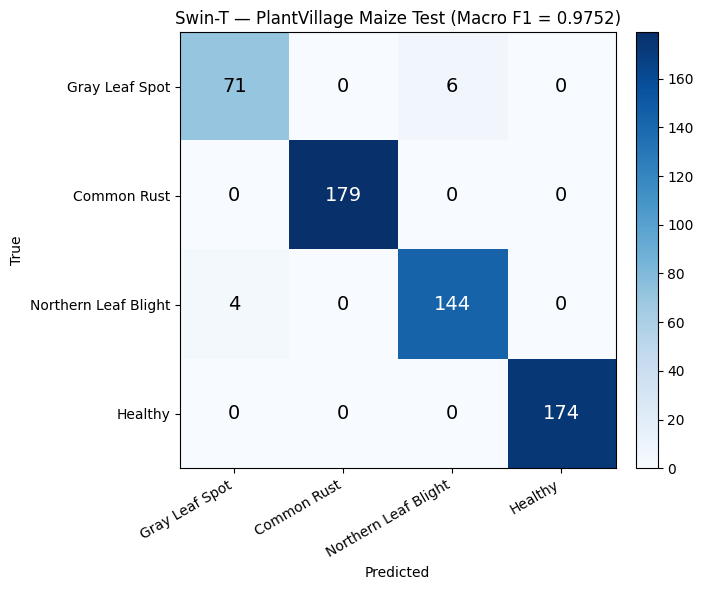

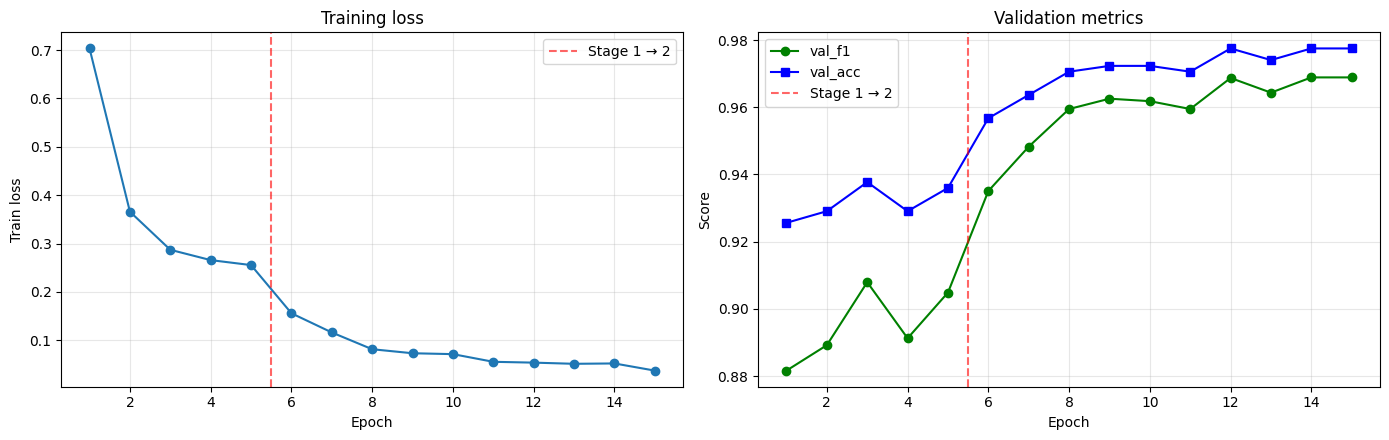


Results saved to: /kaggle/working/nb2_swin_t_results.json

Cell 5 complete ✅

NB2 is officially DONE. 🎉


In [5]:
# ============================================================
# NB2 · Cell 5 — Test eval, comparison vs ResNet50, save JSON
# ============================================================

# --- Load best checkpoint ---
model.load_state_dict(torch.load(CKPT_BEST, map_location=device))
model.eval()
print(f"Loaded best checkpoint from {CKPT_BEST}\n")

# --- Run inference on test set ---
all_preds, all_labs = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        out = model(x)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labs.extend(y.numpy())
all_preds = np.array(all_preds)
all_labs  = np.array(all_labs)

test_acc = float((all_preds == all_labs).mean())
test_f1  = float(f1_score(all_labs, all_preds, average="macro"))
per_class_f1 = f1_score(all_labs, all_preds, average=None)

print("=" * 50)
print(f"Swin-T Test Accuracy : {test_acc:.4f}")
print(f"Swin-T Test Macro F1 : {test_f1:.4f}")
print("=" * 50)
print("\nPer-class metrics:")
print(classification_report(all_labs, all_preds, target_names=DISPLAY_NAMES, digits=4))

# --- Confusion matrix ---
cm = confusion_matrix(all_labs, all_preds)
print("Confusion matrix (rows=true, cols=predicted):")
for i, name in enumerate(DISPLAY_NAMES):
    row = "  ".join(f"{cm[i, j]:>5}" for j in range(4))
    print(f"  {name:<22}  {row}")

# --- Side-by-side comparison with ResNet50 (from NB1) ---
RESNET50 = {
    "test_macro_f1":   0.9698,
    "test_accuracy":   0.9792,
    "per_class_f1": {
        "Gray Leaf Spot":       0.9189,
        "Common Rust":          1.0000,
        "Northern Leaf Blight": 0.9603,
        "Healthy":              1.0000,
    },
}

print("\n" + "=" * 76)
print("PAPER TABLE 1 — ResNet50 vs Swin-T")
print("=" * 76)
print(f"{'Metric':<28}{'ResNet50':>14}{'Swin-T':>14}{'Δ (Swin−RN)':>16}")
print("-" * 76)
print(f"{'Test Macro F1':<28}{RESNET50['test_macro_f1']:>14.4f}"
      f"{test_f1:>14.4f}{test_f1 - RESNET50['test_macro_f1']:>+16.4f}")
print(f"{'Test Accuracy':<28}{RESNET50['test_accuracy']:>14.4f}"
      f"{test_acc:>14.4f}{test_acc - RESNET50['test_accuracy']:>+16.4f}")
print("-" * 76)
print("Per-class F1:")
for i, name in enumerate(DISPLAY_NAMES):
    rn = RESNET50["per_class_f1"][name]
    sw = float(per_class_f1[i])
    print(f"  {name:<26}{rn:>14.4f}{sw:>14.4f}{sw - rn:>+16.4f}")
print("=" * 76)

# --- Plot confusion matrix ---
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(DISPLAY_NAMES, rotation=30, ha="right")
ax.set_yticklabels(DISPLAY_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Swin-T — PlantVillage Maize Test (Macro F1 = {test_f1:.4f})")
for i in range(4):
    for j in range(4):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=14)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
CM_PATH = "/kaggle/working/swin_t_confusion_matrix.png"
plt.savefig(CM_PATH, dpi=150, bbox_inches="tight")
plt.show()

# --- Plot training curves with Stage 1→2 boundary ---
fig2, axes = plt.subplots(1, 2, figsize=(14, 4.5))
epochs_x = list(range(1, len(history["val_f1"]) + 1))
stage_boundary = sum(1 for s in history["stage"] if s == 1)

axes[0].plot(epochs_x, history["train_loss"], marker="o", color="C0")
axes[0].axvline(x=stage_boundary + 0.5, color="red", linestyle="--", alpha=0.6, label="Stage 1 → 2")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss")
axes[0].set_title("Training loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["val_f1"], marker="o", color="green", label="val_f1")
axes[1].plot(epochs_x, history["val_acc"], marker="s", color="blue", label="val_acc")
axes[1].axvline(x=stage_boundary + 0.5, color="red", linestyle="--", alpha=0.6, label="Stage 1 → 2")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("Validation metrics"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
CURVES_PATH = "/kaggle/working/swin_t_training_curves.png"
plt.savefig(CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()

# --- Save results JSON ---
results = {
    "notebook":      "NB2_SwinT_baseline",
    "model":         "Swin-T",
    "pretrained":    "ImageNet V1",
    "dataset":       "PlantVillage_Maize",
    "classes":       DISPLAY_NAMES,
    "n_train":       len(train_paths),
    "n_val":         len(val_paths),
    "n_test":        len(test_paths),
    "config": {
        "img_size":       IMG_SIZE,
        "batch_size":     BATCH_SIZE,
        "stage1_epochs":  STAGE1_EPOCHS,
        "stage1_lr":      STAGE1_LR,
        "stage2_epochs":  STAGE2_EPOCHS,
        "stage2_lr":      STAGE2_LR,
        "weight_decay":   WEIGHT_DECAY,
        "seed":           SEED,
        "optimizer":      "AdamW",
        "scheduler":      "CosineAnnealingLR",
        "stage1_unfrozen": "head only",
        "stage2_unfrozen": "last Swin stage + final norm + head",
    },
    "test_accuracy":   float(test_acc),
    "test_macro_f1":   float(test_f1),
    "per_class_f1":    {DISPLAY_NAMES[i]: float(per_class_f1[i]) for i in range(4)},
    "confusion_matrix": cm.tolist(),
    "history":         history,
    "best_val_f1":     float(best_val_f1),
    "comparison_resnet50": RESNET50,
}

OUT_PATH = "/kaggle/working/nb2_swin_t_results.json"
with open(OUT_PATH, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nResults saved to: {OUT_PATH}")

print("\nCell 5 complete ✅")
print("\nNB2 is officially DONE. 🎉")